### Loading the dataset

In [38]:
import pandas as pd
pre_dataset = pd.read_csv('../datasets/mobile_phone_price.csv')
pre_dataset.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [39]:
pre_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand                   407 non-null    str  
 1   Model                   407 non-null    str  
 2   Storage                 407 non-null    str  
 3   RAM                     407 non-null    str  
 4   Screen Size (inches)    407 non-null    str  
 5   Camera (MP)             407 non-null    str  
 6   Battery Capacity (mAh)  407 non-null    int64
 7   Price ($)               407 non-null    str  
dtypes: int64(1), str(7)
memory usage: 25.6 KB


### Changing to proper numerical types

In [40]:
# Converting the column 'Storage'
dataset = pd.DataFrame(columns=['storage', 'ram', 'screen_size', 'camera_mp', 'battery', 'price'])

def convert_with_plus(screen_size):
    if isinstance(screen_size, str):
        numbers = screen_size.split('+')
        number = ""

        for char in numbers[0].strip():
            if char.isdigit() or char == '.':
                number += char
            else:
                break
        
        return number
    
def convert_to_number(string):
    if isinstance(string, str):
        number = ""

        for char in string.strip():
            if char.isdigit() or char == '.':
                number += char
            else:
                continue
        
        return number


dataset['brand'] = pre_dataset.iloc[:, 0]
dataset['model'] = pre_dataset.iloc[:, 1]
dataset['storage'] = pre_dataset.iloc[:, 2].str.replace('GB', '', regex=False).astype(int)
dataset['ram'] = pre_dataset.iloc[:, 3].str.replace('GB', '', regex=False).astype(int)
dataset['screen_size'] = pre_dataset.iloc[:, 4].apply(convert_with_plus).astype(float)
dataset['camera_mp'] = pre_dataset.iloc[:, 5].apply(convert_with_plus).apply(convert_to_number).astype(float)
dataset['battery'] = pre_dataset.iloc[:, 6].astype(int)
dataset['price'] = pre_dataset['Price ($)'].apply(convert_to_number).astype(int)

dataset.head()


,storage,ram,screen_size,camera_mp,battery,price,brand,model
0,128,6,6.10,12.0,3095,999,Apple,iPhone 13 Pro
1,256,12,6.80,108.0,5000,1199,Samsung,Galaxy S21 Ultra
2,128,8,6.70,48.0,4500,899,OnePlus,9 Pro
3,128,6,6.67,64.0,5020,279,Xiaomi,Redmi Note 10 Pro
4,128,8,6.40,50.0,4614,799,Google,Pixel 6


### Taking a summary on the dataset

In [41]:
dataset.describe()

,storage,ram,screen_size,camera_mp,battery,price
count,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000
mean,123.046683,5.837838,6.471253,43.319410,4676.476658,408.314496
std,64.963160,2.431980,0.320542,24.669025,797.193713,299.684768
min,32.000000,2.000000,4.500000,8.000000,1821.000000,99.000000
25%,64.000000,4.000000,6.440000,13.000000,4300.000000,199.000000
50%,128.000000,6.000000,6.500000,48.000000,5000.000000,299.000000
75%,128.000000,8.000000,6.590000,64.000000,5000.000000,499.000000
max,512.000000,16.000000,7.600000,108.000000,7000.000000,1999.000000


### Visualizing the distribution of data of each column

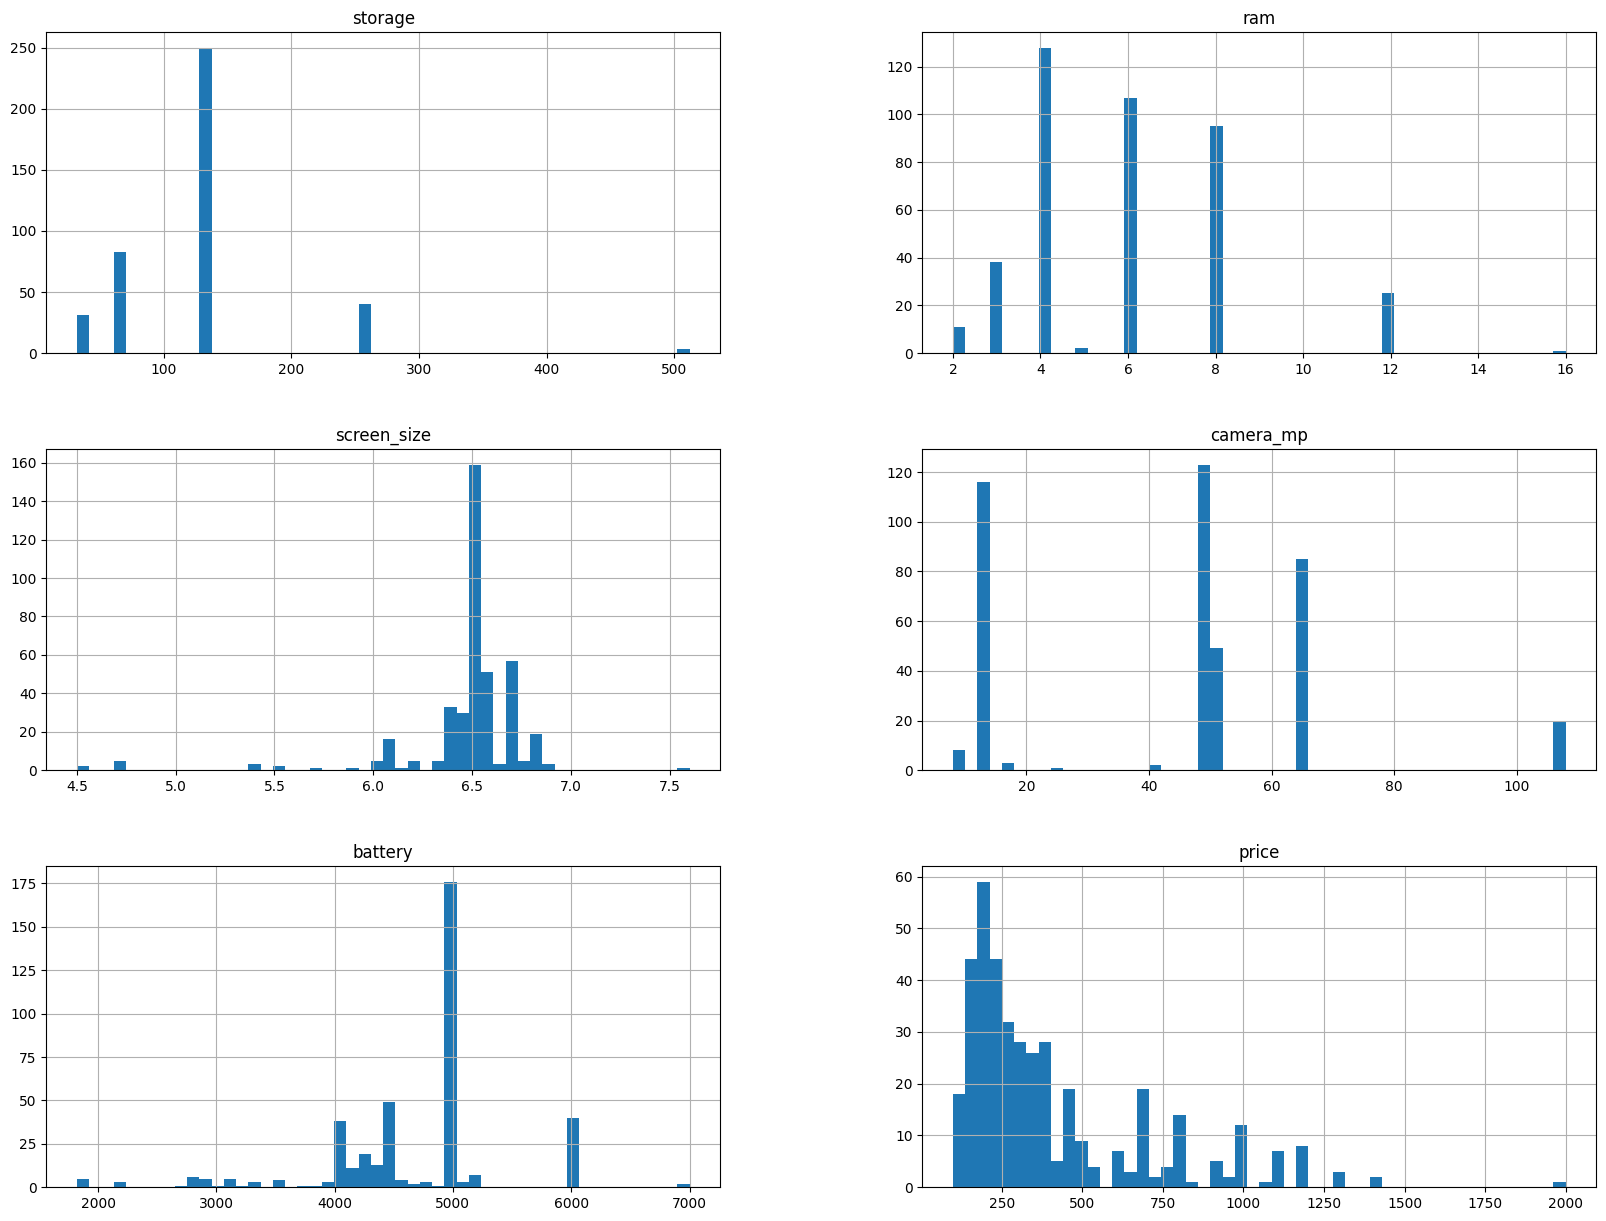

In [42]:
import matplotlib.pyplot as plt

dataset.hist(bins=50, figsize=(20,15))
plt.show()

### Seperating train test and test set

In [43]:
import numpy as np

def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]

    return data.iloc[train_indices], data.iloc[test_indices]

Each and everytime above function create different datasets which make the machine learning model to reveal all the data available.

In [44]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    # Generating random has numbers for each row and checking if they are less than the test ratio
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [45]:
dataset_with_id = dataset.reset_index()
train_set, test_set = split_train_test_by_id(dataset_with_id, 0.2, "index")

In [46]:
test_set.head()

,index,storage,ram,screen_size,camera_mp,battery,price,brand,model
2,2,128,8,6.70,48.0,4500,899,OnePlus,9 Pro
5,5,128,4,6.10,12.0,2815,799,Apple,iPhone 13
12,12,128,8,6.62,64.0,5000,329,Realme,GT Neo2
16,16,128,8,6.20,64.0,4000,799,Samsung,Galaxy S21
23,23,128,8,6.55,48.0,4500,729,OnePlus,9


In [47]:
train_set.head()

,index,storage,ram,screen_size,camera_mp,battery,price,brand,model
0,0,128,6,6.10,12.0,3095,999,Apple,iPhone 13 Pro
1,1,256,12,6.80,108.0,5000,1199,Samsung,Galaxy S21 Ultra
3,3,128,6,6.67,64.0,5020,279,Xiaomi,Redmi Note 10 Pro
4,4,128,8,6.40,50.0,4614,799,Google,Pixel 6
6,6,256,8,6.70,12.0,3300,999,Samsung,Galaxy Z Flip3


In [48]:
# Let's use scikit learn method
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(dataset, test_size=0.2, random_state=42)

We need to maintain **Stratified Sampling** instead of picking random data.

**Example**: When a survey company takes random 1000 people they don't pick randomly instead they take 513 female and 487 male which represents actual population ratio.

In [49]:
# Seperating into multiple categories based on the price
dataset['price_cat'] = pd.cut(dataset['price'], bins=[0, 199, 299, 499, np.inf], labels=[1, 2, 3, 4])

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(dataset, dataset['price_cat']):
    strat_train_set = dataset.loc[train_index]
    strat_test_set = dataset.loc[test_index]

In [50]:
strat_test_set['price_cat'].value_counts() / len(strat_test_set)

price_cat
1    0.292683
2    0.243902
3    0.231707
4    0.231707
Name: count, dtype: float64

Removing the price category column

In [51]:
for _set in (strat_train_set, strat_test_set):
    _set.drop('price_cat', axis=1, inplace=True)

### Data Visualization

#### Looking for corelations

In [52]:
corr_matrix = dataset.corr(numeric_only=True)

In [53]:
corr_matrix['price'].sort_values(ascending=False)

price          1.000000
storage        0.711050
ram            0.637172
camera_mp      0.120588
screen_size    0.046344
battery       -0.396581
Name: price, dtype: float64

#### Visualizing corelation

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='storage', ylabel='price'>,
        <Axes: xlabel='ram', ylabel='price'>,
        <Axes: xlabel='screen_size', ylabel='price'>,
        <Axes: xlabel='camera_mp', ylabel='price'>,
        <Axes: xlabel='battery', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='storage'>,
        <Axes: xlabel='storage', ylabel='storage'>,
        <Axes: xlabel='ram', ylabel='storage'>,
        <Axes: xlabel='screen_size', ylabel='storage'>,
        <Axes: xlabel='camera_mp', ylabel='storage'>,
        <Axes: xlabel='battery', ylabel='storage'>],
       [<Axes: xlabel='price', ylabel='ram'>,
        <Axes: xlabel='storage', ylabel='ram'>,
        <Axes: xlabel='ram', ylabel='ram'>,
        <Axes: xlabel='screen_size', ylabel='ram'>,
        <Axes: xlabel='camera_mp', ylabel='ram'>,
        <Axes: xlabel='battery', ylabel='ram'>],
       [<Axes: xlabel='price', ylabel='screen_size'>,
        <Axes: xlabel='storage', ylabel='sc

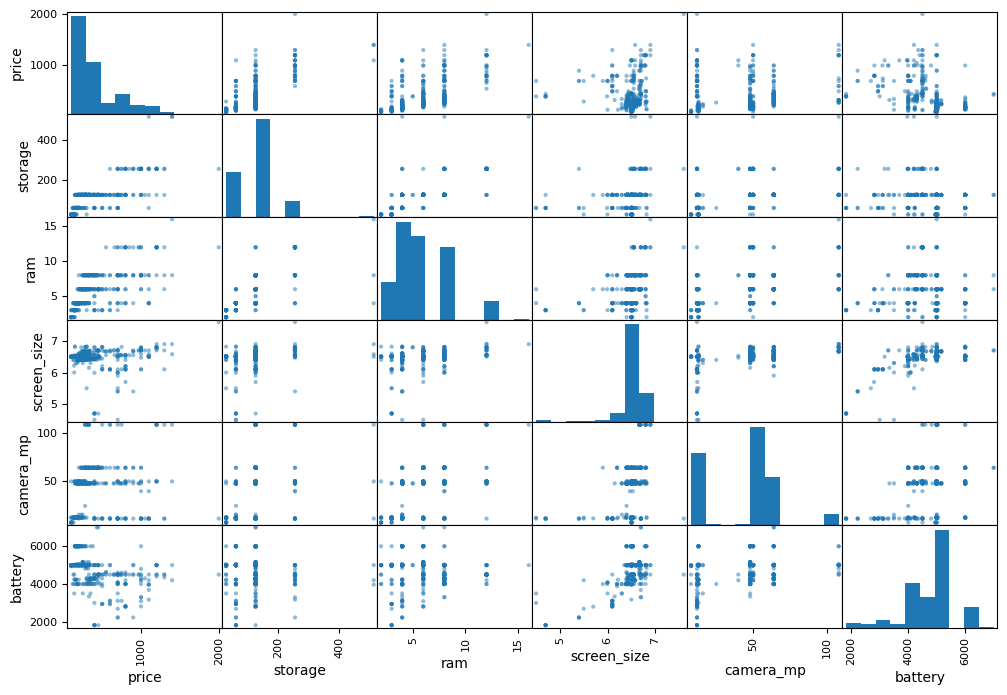

In [54]:
from pandas.plotting import scatter_matrix
attributes = ['price', 'storage', 'ram', 'screen_size', 'camera_mp', 'battery']
scatter_matrix(dataset[attributes], figsize=(12, 8))

#### Experimenting with combination of attributes

array([[<Axes: xlabel='battery_per_screen', ylabel='battery_per_screen'>,
        <Axes: xlabel='storage_per_ram', ylabel='battery_per_screen'>,
        <Axes: xlabel='camera_per_screen', ylabel='battery_per_screen'>,
        <Axes: xlabel='price', ylabel='battery_per_screen'>],
       [<Axes: xlabel='battery_per_screen', ylabel='storage_per_ram'>,
        <Axes: xlabel='storage_per_ram', ylabel='storage_per_ram'>,
        <Axes: xlabel='camera_per_screen', ylabel='storage_per_ram'>,
        <Axes: xlabel='price', ylabel='storage_per_ram'>],
       [<Axes: xlabel='battery_per_screen', ylabel='camera_per_screen'>,
        <Axes: xlabel='storage_per_ram', ylabel='camera_per_screen'>,
        <Axes: xlabel='camera_per_screen', ylabel='camera_per_screen'>,
        <Axes: xlabel='price', ylabel='camera_per_screen'>],
       [<Axes: xlabel='battery_per_screen', ylabel='price'>,
        <Axes: xlabel='storage_per_ram', ylabel='price'>,
        <Axes: xlabel='camera_per_screen', ylabel='price'

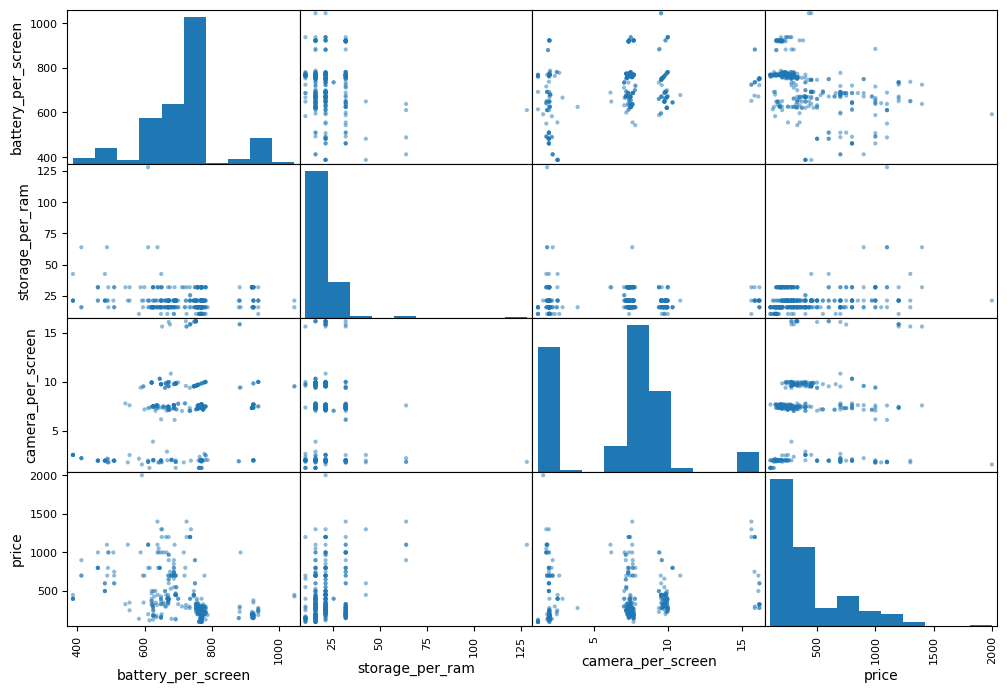

In [55]:
dataset['battery_per_screen'] = dataset['battery'] / dataset['screen_size']
dataset['storage_per_ram'] = dataset['storage'] / dataset['ram']
dataset['camera_per_screen'] = dataset['camera_mp'] / dataset['screen_size']

dataset.corr(numeric_only=True)['price'].sort_values(ascending=False)

attributes = ['battery_per_screen', 'storage_per_ram', 'camera_per_screen', 'price']
scatter_matrix(dataset[attributes], figsize=(12, 8))

**Conclusion:** Battety with storage per ram has some sort of correlation with the price.

### Preparing Data For the Algorithm

#### Data Cleaning

In [56]:
# Copying the training set to a new variable to avoid messing with the original data

mobile = strat_train_set.drop(['price'], axis=1)
mobile_labels = strat_train_set['price'].copy()

mobile_num = mobile.drop(['brand', 'model'], axis=1)

#### Handling Categorical Values

In [57]:
mobile_brands = mobile['brand'].value_counts()
mobile_brands.head()

brand
Samsung    62
Xiaomi     58
Oppo       44
Realme     33
Vivo       27
Name: count, dtype: int64

In [58]:
mobile_models = mobile['model'].value_counts()
mobile_models.head()

model
Y33s           5
C21Y           5
Poco X3 Pro    5
iPhone XR      4
A16s           4
Name: count, dtype: int64

In [59]:
# Converting categorical data to numerical data

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

mobile_brand_encoded = ordinal_encoder.fit_transform(mobile[['brand']])
mobile_model_encoded = ordinal_encoder.fit_transform(mobile[['model']])

In [60]:
ordinal_encoder.categories_

[array(['1.4', '2.4', '3.1 Plus', '3.4', '5.3', '5.4', '6.2', '7', '7 Pro',
        '7i', '8 5G', '8 Pro', '8.3 5G', '8T', '8i', '9', '9 Pro', '9i',
        'A15', 'A15s', 'A16', 'A16s', 'A31', 'A53', 'A53s', 'A53s 5G',
        'A54', 'A54s', 'A54s 5G', 'A74', 'A74 5G', 'A93', 'A94', 'A94 5G',
        'C11', 'C11 2021', 'C15', 'C20', 'C20 Plus', 'C21', 'C21Y', 'C25',
        'C25s', 'C30', 'Edge 20 Fusion', 'Edge 20 Pro', 'Evolve',
        'F19 Pro+', 'F19 Pro+ 5G', 'F19s', 'Find X3 Neo 5G', 'Find X3 Pro',
        'G10', 'G20', 'G50 5G', 'GT Master Edition', 'GT Neo2',
        'Galaxy A02s', 'Galaxy A03s', 'Galaxy A11', 'Galaxy A12',
        'Galaxy A13', 'Galaxy A21s', 'Galaxy A22', 'Galaxy A22 4G',
        'Galaxy A22 5G', 'Galaxy A30s', 'Galaxy A32', 'Galaxy A32 5G',
        'Galaxy A42 5G', 'Galaxy A52 5G', 'Galaxy A52s 5G', 'Galaxy A71',
        'Galaxy A72', 'Galaxy F22', 'Galaxy F41', 'Galaxy F42 5G',
        'Galaxy M12', 'Galaxy M31s', 'Galaxy M32', 'Galaxy M51',
        'Gala

In [61]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
mobile_brand_encoded = one_hot_encoder.fit_transform(mobile[['brand']])
mobile_model_encoded = one_hot_encoder.fit_transform(mobile[['model']])
mobile_brand_encoded.toarray()

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(325, 15))

#### Creating a Transformer

In [62]:
from sklearn.base import BaseEstimator, TransformerMixin

# Transformer to add new attributes to the dataset
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_battery_per_screen=True, add_storage_per_ram=True, add_camera_per_screen=True):
        self.add_battery_per_screen = add_battery_per_screen
        self.add_storage_per_ram = add_storage_per_ram
        self.add_camera_per_screen = add_camera_per_screen
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        battery_per_screen = X[:, 4] / X[:, 2]
        storage_per_ram = X[:, 0] / X[:, 1]
        camera_per_screen = X[:, 3] / X[:, 2]

        if self.add_battery_per_screen and self.add_storage_per_ram and self.add_camera_per_screen:
            return np.c_[X, battery_per_screen, storage_per_ram, camera_per_screen]
        elif self.add_battery_per_screen and self.add_storage_per_ram:
            return np.c_[X, battery_per_screen, storage_per_ram]
        elif self.add_battery_per_screen and self.add_camera_per_screen:
            return np.c_[X, battery_per_screen, camera_per_screen]
        elif self.add_storage_per_ram and self.add_camera_per_screen:
            return np.c_[X, storage_per_ram, camera_per_screen]
        elif self.add_battery_per_screen:
            return np.c_[X, battery_per_screen]
        elif self.add_storage_per_ram:
            return np.c_[X, storage_per_ram]
        elif self.add_camera_per_screen:
            return np.c_[X, camera_per_screen]
        else:
            return X

In [63]:
attr_adder = CombinedAttributesAdder(add_camera_per_screen=False)
mobile_extra_attribs = attr_adder.transform(mobile.values)

#### Scaling the dataset

For the scaling process we can use **Min-Max Scaler** or **Standardization**

#### Comparison: Min-Max Scaling vs. Standardization

| Feature | Min-Max Scaling (Normalization) | Standardization (Z-Score Scaling) |
| :--- | :--- | :--- |
| **Mathematical Formula** | $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$ | $z = \frac{x - \mu}{\sigma}$ |
| **Resulting Range** | **Strictly bounded** (usually $[0, 1]$ or $[-1, 1]$). | **Unbounded**. Typically results in a mean of $0$ and standard deviation of $1$. |
| **Outlier Impact** | **High.** A single outlier can "squash" all other data into a tiny interval. | **Low.** It is more robust because it uses the mean and standard deviation. |
| **Distribution Shape** | **Preserves** the original shape of the distribution. | **Rescales** data; often makes it easier for models to handle skewed data. |
| **Best Used For** | Algorithms that don't assume data distribution (e.g., **KNN**, **Neural Networks**, **Image Processing**). | Algorithms that assume a Gaussian (Normal) distribution (e.g., **Linear Regression**, **SVM**, **PCA**). |
| **Scikit-Learn Class** | `MinMaxScaler` | `StandardScaler` |

#### Creating Data Pipelines

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Add attributes and scale the data using a pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attr_adder', CombinedAttributesAdder(add_camera_per_screen=False)),
    ('std_scaler', StandardScaler())
])

In [65]:
from sklearn.compose import ColumnTransformer

num_attribs = list(mobile_num)
cat_attribs = ['brand', 'model']

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

mobile_prepared = full_pipeline.fit_transform(mobile)
mobile_prepared

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2925 stored elements and shape (325, 232)>

### Select and Train the Model

#### Training and evaluating on the training set

Trying out **Linear Regression**

In [66]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(mobile_prepared, mobile_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Making predictions based on the model

In [67]:
sample_data = mobile.iloc[:5]
sample_labels = mobile_labels.iloc[:5]
sample_data_prepared = full_pipeline.transform(sample_data)
print("Predictions:", lin_reg.predict(sample_data_prepared))
print("Labels:", list(sample_labels))

Predictions: [ 448.99971981  273.00004033  498.99996627 1048.99982472  349.00011255]
Labels: [449, 279, 499, 1099, 349]


Evaluating the model

In [68]:
from sklearn.metrics import mean_squared_error

housing_prediction = lin_reg.predict(mobile_prepared)
lin_mse = mean_squared_error(mobile_labels, housing_prediction)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(15.250092613554381)

Trying out **Decision Tree Regression**

In [69]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(mobile_prepared, mobile_labels)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [70]:
from sklearn.metrics import mean_squared_error

housing_prediction = tree_reg.predict(mobile_prepared)
tree_mse = mean_squared_error(mobile_labels, housing_prediction)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(13.680418347179526)

Applying cross validation to get a better score

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, mobile_prepared, mobile_labels, scoring='neg_mean_squared_error', cv=10)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard Deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [206.46378319 159.66347185 101.81739117 145.88664249 204.2287063
 145.30141087 124.44643049 181.88804602  98.67437329 143.75815194]
Mean: 151.21284076225587
Standard Deviation: 35.932238341118186


#### Saving the model

In [73]:
import joblib

joblib.dump(tree_reg, 'mobile_price_predictor.pkl')

['mobile_price_predictor.pkl']

### Finetuning the model

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {
        "n_estimators": [3, 10, 30],
        "max_features": [2,4,6,8]
    },
    {
        "bootstrap": [False],
        "n_estimators": [3, 10],
        "max_features": [2, 3, 4]
    }
]

forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(mobile_prepared, mobile_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t